In [1]:
import sys
!{sys.executable} -m pip install torch matplotlib pandas numpy --q

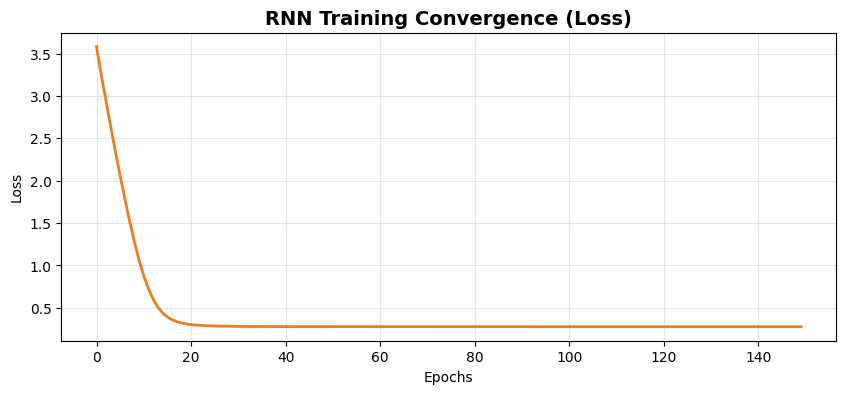


MODEL COMPARISON: N-GRAM vs RNN
     Input N-Gram (Bigram) RNN Prediction
artificial    intelligence   intelligence
      deep        learning       learning
   natural        language       language
   machine        learning       learning
    neural        networks       networks


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

# --- 1. Dataset Preparation ---
corpus = """
natural language processing is a part of artificial intelligence
artificial intelligence is the future of modern technology
deep learning models use neural networks to process data
neural networks mimic the human brain to learn patterns
natural language processing helps computers understand speech
machine learning is a subset of artificial intelligence
"""

# Tokenization
tokens = corpus.lower().split()
vocab = sorted(list(set(tokens)))
word_to_ix = {word: i for i, word in enumerate(vocab)}
ix_to_word = {i: word for i, word in enumerate(vocab)}
vocab_size = len(vocab)

# --- 2. Bigram (N-gram) Model Implementation ---
class BigramModel:
    def __init__(self):
        self.counts = defaultdict(Counter)
    
    def train(self, words):
        for i in range(len(words) - 1):
            self.counts[words[i]][words[i+1]] += 1
            
    def predict(self, word):
        word = word.lower()
        if word in self.counts:
            # Return word with highest count
            return self.counts[word].most_common(1)[0][0]
        return "<Unknown>"

# --- 3. RNN Model Implementation ---
class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(SimpleRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

# --- 4. Training Process ---

# Train Bigram
ngram_model = BigramModel()
ngram_model.train(tokens)

# Train RNN
X_train = torch.LongTensor([word_to_ix[tokens[i]] for i in range(len(tokens)-1)]).view(-1, 1)
Y_train = torch.LongTensor([word_to_ix[tokens[i+1]] for i in range(len(tokens)-1)])

rnn_model = SimpleRNN(vocab_size, 32, 64)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(rnn_model.parameters(), lr=0.01)

loss_history = []
for epoch in range(150):
    optimizer.zero_grad()
    outputs = rnn_model(X_train)
    loss = criterion(outputs, Y_train)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

# --- 5. Performance Analysis & Visualization ---

def get_rnn_predict(word):
    if word.lower() not in word_to_ix: return "<Unknown>"
    idx = torch.LongTensor([[word_to_ix[word.lower()]]])
    with torch.no_grad():
        out = rnn_model(idx)
        _, pred_idx = torch.max(out, 1)
        return ix_to_word[pred_idx.item()]

test_words = ["artificial", "deep", "natural", "machine", "neural"]
comparison_data = []

for w in test_words:
    comparison_data.append({
        "Input": w,
        "N-Gram (Bigram)": ngram_model.predict(w),
        "RNN Prediction": get_rnn_predict(w)
    })

df = pd.DataFrame(comparison_data)

# Visualization of RNN Learning
plt.figure(figsize=(10, 4))
plt.plot(loss_history, color='#e67e22', lw=2)
plt.title('RNN Training Convergence (Loss)', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.show()

print("\n" + "="*55)
print("MODEL COMPARISON: N-GRAM vs RNN")
print("="*55)
print(df.to_string(index=False))
print("="*55)